In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
searchterm = "iPhone"
# searchterm = "Airpods"

In [ ]:
def get_data(searchterm, page=1):
  URL = f"https://www.ebay.com/sch/i.html?_nkw={searchterm}&_sacat=0&_from=R40&LH_PrefLoc=3&LH_Auction=1&rt=nc&LH_Sold=1&LH_Complete=1&_pgn={page}"
  r = requests.get(URL)
  soup = BeautifulSoup(r.text, "html.parser")
  return soup

In [ ]:
def parse(soup):
    productslist = []
    results = soup.find_all('li', {'class': 's-item'})
    for item in results:
        try:
            title = item.find("div", {"class": "s-item__title"}).text
            price = item.find("span", {"class": "s-item__price"}).text
            sold_date = item.find("span", {"class": "s-item__caption--signal POSITIVE"}).text
            bids = item.find("span", {"class": "s-item__bids"}).text
            link = item.find("a", {"class": "s-item__link"})["href"]

            product = {
                "Title": title,
                "Sold_Price": float(price.replace("$", "").replace(",", "").strip()),
                "Sold_Date": sold_date,
                "Bids": bids,
                "Link": link
            }
            productslist.append(product)
        except:
            continue
    return productslist

In [ ]:
def output(productslist, searchterm):
    productsdf = pd.DataFrame(productslist)
    productsdf.to_csv(searchterm + "_output.csv", index=False)
    productsdf.to_excel(searchterm + "_output.xlsx", index=False)
    print("Saved to CSV and Excel")
    return productsdf

In [ ]:
# Scrape across multiple pages
all_products = []
max_pages = 3  # We change this to scrape more pages

In [ ]:
for page in range(1, max_pages + 1):
    print(f"Scraping Page {page}...")
    soup = get_data(searchterm, page)
    current_products = parse(soup)
    if not current_products:
        print("No more results.")
        break
    all_products.extend(current_products)

Scraping Page 1...
Scraping Page 2...
Scraping Page 3...


In [ ]:
# Save & Load
df = output(all_products, searchterm)

Saved to CSV and Excel


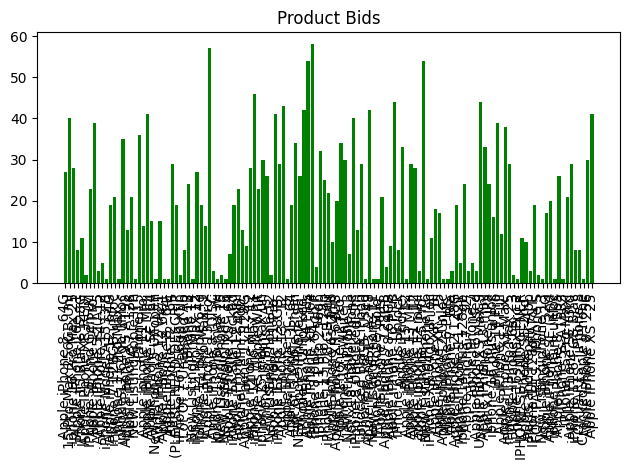

Number of items: 129


In [31]:
# Visualization
My_Dict = {}
for idx in range(len(df)):
    try:
        title = df['Title'][idx][:20]
        bid_count = int(df['Bids'][idx].split()[0])
        My_Dict[title] = bid_count
    except:
        continue

plt.xticks(rotation=90)
plt.bar(list(My_Dict.keys()), My_Dict.values(), color='g')
plt.title("Product Bids")
plt.tight_layout()
plt.show()
print(f"Number of items: {len(My_Dict)}")

# The graph's a little messy, but I'll endeavor to clean it up and make it an interactive one.

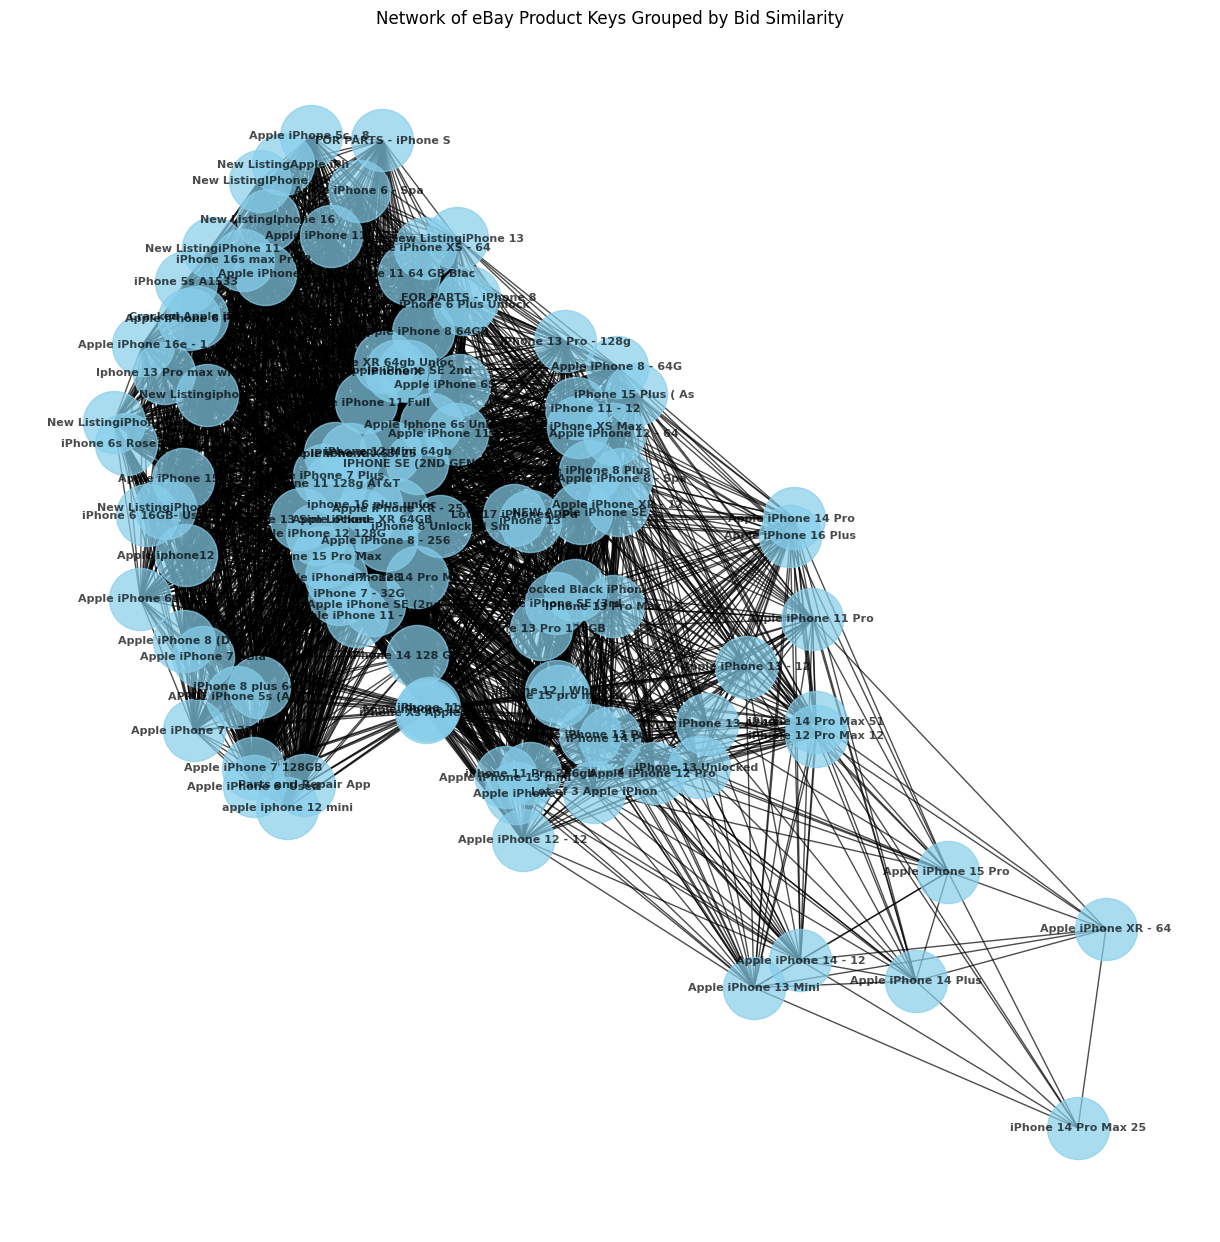

In [ ]:
# Network Graph
G = nx.Graph()
threshold = 20

for key, value in My_Dict.items():
    G.add_node(key, weight=value)

for key1, val1 in My_Dict.items():
    for key2, val2 in My_Dict.items():
        if key1 != key2 and abs(val1 - val2) <= threshold:
            G.add_edge(key1, key2, weight=abs(val1 - val2))

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8, node_color="skyblue", font_weight="bold", alpha=0.7)
plt.title("Network of eBay Product Keys Grouped by Bid Similarity")
plt.show()

In [ ]:
from collections import defaultdict

In [ ]:
# Build Co-Occurrence Graph based on Titles
co_occurrence = defaultdict(lambda: defaultdict(int))

In [ ]:
# Tokenize titles and track co-occurrence
for title in df["Title"]:
    tokens = set(title.lower().split())  # Tokenizing by spaces and converting to lowercase
    for t1 in tokens:
        for t2 in tokens:
            if t1 != t2:  # Skip self-co-occurrence
                co_occurrence[t1][t2] += 1

# print(co_occurrence)

In [ ]:
# Create the Co-Occurrence Graph
G = nx.Graph()

In [ ]:
for t1 in co_occurrence:
    for t2 in co_occurrence[t1]:
        weight = co_occurrence[t1][t2]
        if weight > 2:  # Only consider co-occurrences with a weight > 2 to reduce noise
            G.add_edge(t1, t2, weight=weight)

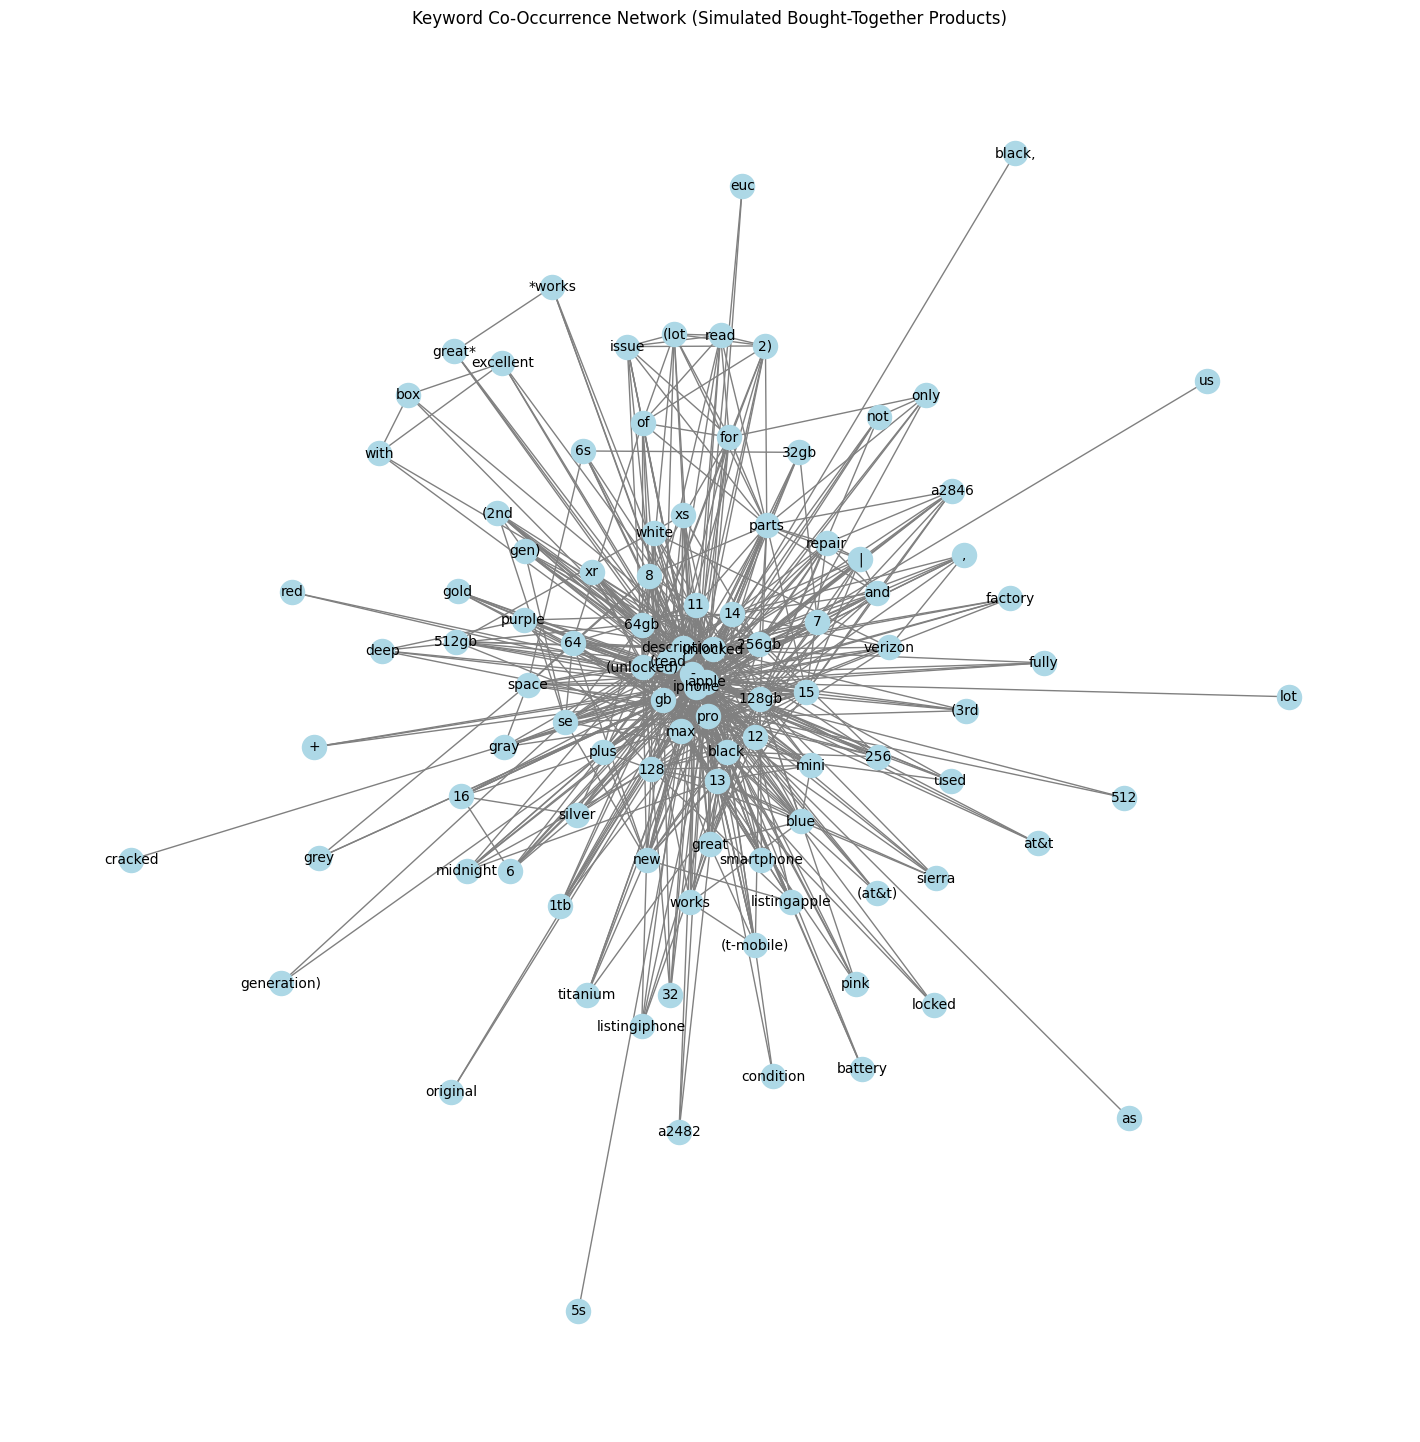

In [ ]:
# Visualize the Co-Occurrence Network
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", font_size=10)
plt.title("Keyword Co-Occurrence Network (Simulated Bought-Together Products)")
plt.show()

In [ ]:
# Identify Key Nodes (Most Popular Products) based on Centrality
centrality = nx.degree_centrality(G)
top_products = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Products by Centrality (Most Connected):")
for product, score in top_products:
    print(f"{product}: {score:.3f}")

Top Products by Centrality (Most Connected):
iphone: 0.980
apple: 0.778
-: 0.727
unlocked: 0.535
gb: 0.455
(unlocked): 0.394
128gb: 0.384
pro: 0.374
black: 0.253
13: 0.253


In [ ]:
# Community Detection (Related Categories or Titles)
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

print(f"Detected {len(communities)} communities:")
for i, comm in enumerate(communities[:5], 1):  # Print first 5 communities
    print(f"\nCommunity {i}:")
    print(", ".join(list(comm)[:10]))  # Print top 10 words per community

Detected 4 communities:

Community 1:
silver, (at&t), a2482, grey, us, (lot, red, at&t, for, original

Community 2:
unlocked, 7, gen), 1tb, plus, xs, 64gb, generation), box, se

Community 3:
15, 11, 256gb, purple, max, listingiphone, pro, ,, smartphone, factory

Community 4:
sierra, 128, new, white, 12, (unlocked), great, listingapple, midnight, mini


In [ ]:
# Save results to a file (e.g., community details, centrality)
with open('community_results.txt', 'w') as file:
    file.write("Top Products by Centrality:\n")
    for product, score in top_products:
        file.write(f"{product}: {score:.3f}\n")

    file.write("\nDetected Communities:\n")
    for i, comm in enumerate(communities[:5], 1):
        file.write(f"\nCommunity {i}:\n")
        file.write(", ".join(list(comm)[:10]) + "\n")

print("Analysis complete and results saved to 'community_results.txt'.")

Analysis complete and results saved to 'community_results.txt'.


##HeatMaps:

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

In [43]:
data = {
    'Title': ['iPhone 11 128GB', 'iPhone X 64GB', 'iPhone 12 256GB', 'Apple Phone 32GB', 'iPhone 11 64GB'],
    'Sold_Price': [500, 300, 600, 200, 450]
}
df = pd.DataFrame(data)

In [44]:
# Function to extract iPhone model from title
def extract_model(title):
    models = [
        'iPhone 6', 'iPhone 6S', 'iPhone 7', 'iPhone 8', 'iPhone X',
        'iPhone XR', 'iPhone XS', 'iPhone 11', 'iPhone 12', 'iPhone 13',
        'iPhone 14', 'iPhone 15', 'iPhone SE'
    ]
    for model in models:
        if model.lower() in title.lower():
            return model
    return 'Other'

In [47]:
def extract_storage(title):
    storage_pattern = r'\b(64GB|128GB|256GB|512GB|1TB)\b'
    match = re.search(storage_pattern, title, re.IGNORECASE)
    return match.group(0) if match else 'Unknown'

# Apply extraction functions
df['Model'] = df['Title'].apply(extract_model)
df['Storage'] = df['Title'].apply(extract_storage)

In [48]:
# Create a pivot table: average sold price by model and storage
pivot_table = df.pivot_table(values='Sold_Price', index='Model', columns='Storage', aggfunc='mean')

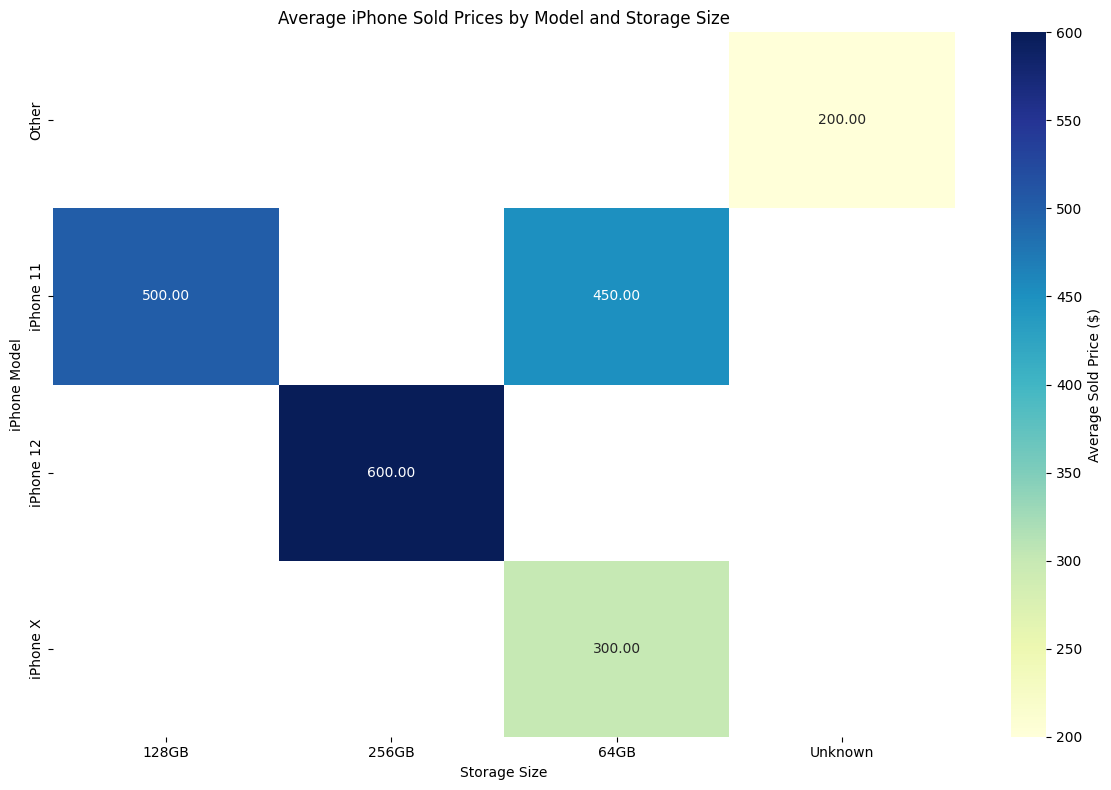

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Average Sold Price ($)'})
plt.title('Average iPhone Sold Prices by Model and Storage Size')
plt.xlabel('Storage Size')
plt.ylabel('iPhone Model')
plt.tight_layout()
plt.show()